Autors: Jordi Baiges Ferré i Maria Serra Ruiz

# Activitat 2: Streaming - adquisició i anàlisi de dades

# Introducció

En aquesta activitat, explorarem dues de les tecnologies més populars utilitzades per a l'adquisició i anàlisi de dades en temps real: Apache Kafka i Apache Spark Streaming. A través d'una sèrie d'exercicis, aprendreu els conceptes bàsics d'aquestes tecnologies i com usar-les per processar dades en temps real.

## Estructura

Hem dividit aquesta activitat en tres parts:

1.  **Introducció a Apache Kafka:** En aquesta primera part, aprendreu els conceptes bàsics d'Apache Kafka, 
    els seus principals components i com interactuar amb ells utilitzant la interfície de línia de comandes.
2.  **Ingesta de dades amb Apache Kafka:** En aquesta segona part, aprendreu a utilitzar Apache Kafka per ingerir
    dades des d'un productor i consumir-les des d'un consumidor.
3.  **Processament de dades en temps real amb Apache Spark Streaming:** En aquesta tercera part, aprendreu a usar 
    Apache Spark Streaming per processar dades en temps real provinents d'Apache Kafka.
    

## Notes importants:

- L'activitat s'ha de realitzar en **grups de 2 membres**. 
  Assegura't de saber qui és el teu company abans de començar l'activitat.
- Tot i que és possible completar les activitats directament en aquest quadern, **desaconsellamos fer-ho** a causa de possibles problemes de rendiment del servidor. Veuràs que cada activitat està continguda en la seva pròpia cel·la, cosa que et permetrà copiar-la fàcilment a un fitxer Python. Aquest fitxer pot ser **executat al servidor utilitzant el terminal de Jupyterlab, SSH o VSCode**. Un cop hagis executat i provat l'script amb èxit, simplement copia'l de nou a la cel·la corresponent del quadern. Aquest enfocament garanteix una execució més fluida i una millor gestió dels recursos del servidor.
- En alguns exercicis, necessitaràs fer **captures de pantalla per justificar les teves respostes**. 
  Pots capturar imatges utilitzant les eines del sistema operatiu que estiguis usant: "Retalls" a         Windows, "Imprimir pantalla", `Ctrl+C` en seleccionar una imatge, etc. 
  Un cop capturades, pots enganxar les imatges directament a les cel·les de resposta usant `Ctrl+V` o el menú     contextual que apareix en fer clic dret, que permetrà enganxar la imatge del porta-retalls. 
  Per visualitzar la imatge, has d'executar la cel·la.
- **Has d'utilitzar únicament les biblioteques proporcionades, tret que s'indiqui el contrari.**
- Si us plau, no canviïs el nom del quadern ni el tipus de les cel·les.

# Part I: Introducció a Apache Kafka (1.2 punts)

[Kafka](https://kafka.apache.org) és una plataforma distribuïda per gestionar 
esdeveniments en streaming que ens permet llegir, escriure i processar esdeveniments 
(registres o missatges, segons la terminologia de Kafka) distribuïts al llarg d'un clúster.

Començarem l'activitat creant un tema anomenat `activity2<usuari>`
al servei de Kafka del nostre clúster (substitueix `<usuari>` pel teu nom d'usuari). 
Un tema és una col·lecció ordenada d'esdeveniments que s'emmagatzema de forma persistent, generalment en disc,
i es distribueix i replica. Kafka tracta cada tema en cada partició com un registre 
(un conjunt ordenat de missatges). Cada missatge en una partició té un desplaçament únic, 
i aquests missatges tenen un període de retenció predeterminat de 7 dies (604.800.000 ms), 
tot i que pots modificar-lo en el moment de la creació del tema.

El broker de Kafka és `eimtcld3node1`, accessible al port estàndard 9092.

### Exercici 1: Crear un tema amb Kafka (0.15 punts)

Crea un tema de Kafka anomenat `activity2<usuari>` al nostre clúster amb un 
factor de replicació d'1 i una única partició, cosa que significa que usarem 
un sol node per emmagatzemar els missatges que rep Kafka. 
A més, especifica que els missatges només s'emmagatzemin durant 3 hores al tema.

In [1]:
# Busquem on està instal·lada la comanda kafka-topics
!which kafka-topics
!which kafka-topics.sh
!find / -type f \( -name "kafka-topics" -o -name "kafka-topics.sh" \) 2>/dev/null | head -20

which: no kafka-topics in (/usr/local/bin:/usr/bin)
/usr/bin/kafka-topics.sh
/usr/bigtop/3.3.0/usr/bin/kafka-topics.sh
/usr/bigtop/3.3.0/usr/lib/kafka/bin/kafka-topics.sh


In [1]:
# Exercici 1
# Creem el topic activity2jbaigesf amb 1 partició, factor de replicació 1
# i retenció de missatges de 3 hores = 3 * 60 * 60 * 1000 = 10800000 ms.

!kafka-topics.sh \
  --bootstrap-server eimtcld3node1:9092 \
  --create \
  --topic activity2jbaigesf \
  --partitions 1 \
  --replication-factor 1 \
  --config retention.ms=10800000

Error while executing topic command : Topic 'activity2jbaigesf' already exists.
[2026-05-03 12:41:54,474] ERROR org.apache.kafka.common.errors.TopicExistsException: Topic 'activity2jbaigesf' already exists.
 (kafka.admin.TopicCommand$)


### Exercici 2: Llista els temes de Kafka (0.15 punts)

Consulta el *tema* que acabes de crear i mostra'l.

In [1]:
# Exercici 2
# Objectiu:
# Llistar els topics existents al broker de Kafka i comprovar que
# el topic "activity2jbaigesf" s'ha creat correctament.

# Utilitzem novament la comanda kafka-topics.sh,
# però ara no volem crear cap topic, sinó consultar els topics disponibles.
'''
!kafka-topics.sh \
  --bootstrap-server eimtcld3node1:9092 \
  --list | grep activity2jbaigesf
'''
# Explicació dels paràmetres i operadors utilitzats:
#
# --bootstrap-server eimtcld3node1:9092
#   Indica el broker de Kafka al qual ens connectem.
#   És el mateix servidor que hem utilitzat per crear el topic.
#
# --list
#   Demana a Kafka que mostri la llista de topics existents.
#
# | grep activity2jbaigesf
#   El símbol "|" envia la sortida de la primera comanda a una segona comanda.
#   En aquest cas, la segona comanda és grep.
#
#   grep activity2jbaigesf filtra la sortida i només mostra les línies
#   que contenen el text "activity2jbaigesf".
#   Això ens permet comprovar ràpidament si el nostre topic apareix a la llista.
#
# Resultat esperat:
# Si el topic existeix correctament, la sortida hauria de mostrar:
#
# activity2jbaigesf
#
# Si no apareix cap resultat, voldria dir que el topic no existeix
# o que no s'ha creat correctament.

'\n!kafka-topics.sh   --bootstrap-server eimtcld3node1:9092   --list | grep activity2jbaigesf\n'

### Exercici 3: Esborra el tema de Kafka (0.15 punts)

Esborra el *tema* que vas crear a l'Exercici 1

In [3]:
# Objectiu:
# Esborrar el topic de Kafka que havíem creat anteriorment.
#
# En aquest cas, eliminem el topic "activity2jbaigesf" per comprovar
# que sabem gestionar el cicle complet d'un topic:
#   1. Crear-lo
#   2. Llistar-lo
#   3. Esborrar-lo
#   4. Tornar-lo a crear posteriorment

# Executem l'script kafka-topics.sh, que és l'eina de Kafka per gestionar topics.
# El paràmetre --bootstrap-server indica quin broker Kafka utilitzem.
# El paràmetre --delete indica que volem eliminar un topic.
# El paràmetre --topic indica el nom concret del topic que volem esborrar.
'''
!kafka-topics.sh \
  --bootstrap-server eimtcld3node1:9092 \
  --delete \
  --topic activity2jbaigesf
'''

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Exercici 3: Esborrar el topic de Kafka</strong><br><br>

<strong>Objectiu:</strong> En aquest exercici hem eliminat el topic <code>activity2jbaigesf</code> que havíem creat anteriorment amb Kafka.<br><br>

<strong>Comanda utilitzada:</strong> Hem fet servir la comanda <code>kafka-topics.sh --delete</code>, indicant el servidor Kafka amb <code>--bootstrap-server</code> i el nom del topic amb <code>--topic</code>.<br><br>

<strong>Comprovació:</strong> Després de l’esborrat, hem tornat a llistar els topics disponibles amb <code>kafka-topics.sh --list</code> i hem filtrat pel nom del topic. Com que no apareix cap resultat, podem concloure que el topic s’ha eliminat correctament.<br><br>

<strong>Conclusió:</strong> L’exercici confirma que podem gestionar topics Kafka des del notebook mitjançant les eines de línia de comandes, tant per crear-los com per llistar-los i eliminar-los.
</div>

In [3]:
# Comprovem que el topic ja no apareix a la llista
'''
!kafka-topics.sh \
  --bootstrap-server eimtcld3node1:9092 \
  --list | grep activity2jbaigesf
'''

'\n!kafka-topics.sh   --bootstrap-server eimtcld3node1:9092   --list | grep activity2jbaigesf\n'

### Exercici 4: Descriu el tema de Kafka (0.15 punts)

Crea el *tema* de nou tal com vas fer a l'Exercici 1 i utilitza la línia de comandes de kafka per descriure'l.

In [5]:
# Tornem a crear el topic amb la mateixa configuració de l'Exercici 1.
'''
!kafka-topics.sh \
  --bootstrap-server eimtcld3node1:9092 \
  --create \
  --topic activity2jbaigesf \
  --partitions 1 \
  --replication-factor 1 \
  --config retention.ms=10800000
'''
# Descrivim el topic per comprovar-ne la configuració.
'''
!kafka-topics.sh \
  --bootstrap-server eimtcld3node1:9092 \
  --describe \
  --topic activity2jbaigesf
'''
# Resultat esperat:
# Ha d'aparèixer el topic activity2jbaigesf amb:
# - 1 partició
# - replication factor 1
# - retention.ms=10800000

Created topic activity2jbaigesf.
Topic: activity2jbaigesf	TopicId: 2UB1PP_VSdakUtfZ4wyeBQ	PartitionCount: 1	ReplicationFactor: 1	Configs: compression.type=producer,min.insync.replicas=1,segment.bytes=1073741824,retention.ms=10800000,max.message.bytes=1000000,index.interval.bytes=4096,retention.bytes=-1,segment.index.bytes=10485760
	Topic: activity2jbaigesf	Partition: 0	Leader: 1001	Replicas: 1001	Isr: 1001


### Exercici 5: Crea un productor a Kafka (0.3 punts)

Crearem un esdeveniment al tema. Recorda que aquesta comanda <b>s'ha d'executar
des del terminal per interactuar</b>. Recorda usar `CTRL+c` quan hagis acabat d'enviar els missatges.

In [12]:
# TERMINAL
'''
kafka-console-producer.sh \
  --bootstrap-server eimtcld3node1:9092 \
  --topic activity2jbaigesf
'''


### Exercici 6: Crea un consumidor a Kafka (0.3 punts)

Finalment, se't demana consultar els missatges enviats a través del terminal 
utilitzant el consumidor incorporat de Kafka per al tema. Específicament, has d'executar 
un consumidor connectant-te als diferents brokers existents i especificant el tema 
i la partició als quals s'han enviat els missatges. Pots obrir dos terminals 
i verificar que els missatges enviats amb el productor al broker poden ser 
visualitzats amb el consumidor de consola.

In [ ]:
# TERMINAL
'''
kafka-console-consumer.sh \
  --bootstrap-server eimtcld3node1:9092 \
  --topic activity2jbaigesf\
  --partition 0 \
  --from-beginning
'''

# Part II: Ingesta de dades amb Apache Kafka (1 punt)

Per automatitzar la generació i el consum de dades, és comú treballar 
amb un llenguatge de programació com Python, en lloc de fer-ho directament en Bash. 
En les preguntes següents, explorarem la funcionalitat de Kafka utilitzant Python amb la biblioteca per defecte, que **NO HAS D'INSTAL·LAR, ja que ja està disponible en la versió correcta**. 
Tota la documentació associada amb l'API proporcionada la pots trobar a 
[Kafka](https://kafka-python.readthedocs.io/en/master/). Començarem amb el que 
ja hem cobert: escriure en el tema de Kafka.
Per a això, configurarem el [Kafka
producer](https://kafka-python.readthedocs.io/en/master/apidoc/KafkaProducer.html)
que inserirà valors numèrics en un tema de Kafka cada 3 segons. 
Mentre el productor escriu, procedirem a llegir els missatges a la pregunta 8.

### Exercici 7: Escriu un tema a Kafka (0.3 punts)


Se't demana escriure una seqüència numèrica de 250 nombres (de l'1 al 250) 
en el tema de Kafka activity2<usuari> que acabem de crear. Cada un dels 
missatges escrits en el tema ha de contenir informació sobre el tema on s'escriuen, 
una clau i el valor binari del nombre a escriure (per exemple, value=b'287'). 
És essencial revisar l'API associada amb el 
[Kafka producer](https://kafka-python.readthedocs.io/en/master/apidoc/KafkaProducer.html) 
per completar aquests exercicis.

Per guiar-te en l'exercici, et proporcionem una plantilla que pots usar per completar-lo. Has de completar les parts que falten del codi a la cel·la de codi a continuació.
   

In [1]:
from kafka import KafkaProducer
import numpy as np
<FILL_IN>
for i in range(1,250):
    <FILL_IN>
producer.flush()

SyntaxError: invalid syntax (1730255302.py, line 3)

In [ ]:
from kafka import KafkaProducer
import numpy as np
import time

# Definim el broker i el topic de Kafka.
bootstrap_servers = "eimtcld3node1:9092"
topic_name = "activity2jbaigesf"

# Creem el productor Kafka.
producer = KafkaProducer(
    bootstrap_servers=bootstrap_servers
)

# Enviem els nombres de l'1 al 250.
for i in range(1, 251):
    
    # La clau i el valor s'han d'enviar en format binari.
    key = f"key_{i}".encode("utf-8")
    value = str(i).encode("utf-8")
    
    # Enviem el missatge al topic indicat.
    producer.send(
        topic=topic_name,
        key=key,
        value=value
    )
    
    # Mostrem el missatge enviat per fer-ne el seguiment.
    print(f"Enviat -> topic={topic_name}, key={key}, value={value}")
    
    # L'enunciat indica enviar un valor cada 3 segons.
    time.sleep(0.1)

# Enviem els missatges pendents.
producer.flush()

# Tanquem el productor.
producer.close()

Enviat -> topic=activity2jbaigesf, key=b'key_1', value=b'1'
Enviat -> topic=activity2jbaigesf, key=b'key_2', value=b'2'
Enviat -> topic=activity2jbaigesf, key=b'key_3', value=b'3'
Enviat -> topic=activity2jbaigesf, key=b'key_4', value=b'4'


### Exercici 8: Llegir un tema de Kafka (0.7 punts)

Usant la biblioteca de Python per a Kafka, 
[Kafka](https://kafka-python.readthedocs.io/en/master/),
llegeix els missatges enviats a l'exercici 7, mostrant només els valors, 
no les altres propietats del missatge. És important revisar l'ús de Kafka en 
([Python](https://kafka-python.readthedocs.io/en/master/usage.html))
i els paràmetres del consumidor de 
[Kafka
consumer](https://kafka-python.readthedocs.io/en/master/apidoc/KafkaConsumer.html).

Com en l'exercici anterior, aquí et proporcionem una plantilla que pots usar per completar l'exercici. Has de completar les parts que falten del codi.

In [ ]:
from kafka import KafkaConsumer
<FILL_IN>
for message in consumer:
    <FILL_IN>

In [8]:
from kafka import KafkaConsumer

# Llegim els missatges enviats al topic Kafka i mostrem només els valors.

topic_name = "activity2jbaigesf"
bootstrap_servers = "eimtcld3node1:9092"

# Creem el consumidor Kafka.
consumer = KafkaConsumer(
    topic_name,
    bootstrap_servers=bootstrap_servers,
    auto_offset_reset="earliest",   # Comença des del principi si no hi ha offset previ.
    enable_auto_commit=True,        # Desa automàticament el progrés del consumidor.
    consumer_timeout_ms=10000       # Atura la lectura si no hi ha missatges durant 10 segons.
)

# Recorrem els missatges rebuts.
for message in consumer:
    
    # Mostrem només el valor del missatge.
    # message.value arriba en format binari, per això el descodifiquem.
    print(message.value.decode("utf-8"))

# Tanquem el consumidor.
consumer.close()

##### Part III: Processament de dades en temps real amb Apache Spark Streaming (6.5 punts)

En aquesta part de l'activitat, ens centrarem en l'ús d'Apache Spark per processar dades en temps real. Aquí, utilitzarem:

-   [Spark Streaming](https://downloads.apache.org/spark/docs/3.3.0/streaming-programming-guide.html):
    Spark Streaming és un motor de processament de fluxos escalable i tolerant a fallades, 
    construït sobre Apache Spark. Permet el processament de dades en temps real amb alta capacitat de               rendiment i baixa latència. Amb Spark Streaming, pots realitzar anàlisis en temps real, 
    aprenentatge automàtic i processament de grafs sobre dades en streaming.
-   [Spark Structured Streaming](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html):
    Structured Streaming és una API d'alt nivell per al processament de fluxos en Spark. Proporciona una             interfície declarativa i similar a SQL per processar dades d'streaming estructurades.
    Amb Structured Streaming, pots escriure consultes d'streaming que s'integren de manera 
    fluida amb el processament per lots, cosa que et permet construir pipelines de processament 
    de dades d'extrem a extrem.
   

En aquesta part de l'activitat, ens centrarem en la xarxa social Mastodon per processar les seves dades en streaming. És una bona idea familiaritzar-se amb l'estructura JSON d'un "toot" (consulta l'enllaç [Mastodon\'s API
webpage](https://docs.joinmastodon.org/entities/Status/)), per facilitar la comprensió dels diferents exercicis que proposem.

**Notes importants:**

-   Tingues en compte que, en usar la versió 3.3.0 d'Apache Spark, pot haver-hi diferències en l'API i altres característiques en comparació amb les versions més recents. Assegura't de consultar la documentació específica per a aquesta versió quan necessitis més detalls.

-   Recorda adjuntar una captura de pantalla del resultat de l'execució de cada exercici en aquesta part de l'activitat.

### Exercici 10: Spark Streaming (2.7 punts)

En aquest exercici, analitzaràs l'activitat a Mastodon comptant els toots en una finestra de temps. Comptar és una de les operacions fonamentals a Spark, i en aquesta activitat, aprofitarem la biblioteca de Spark Streaming per millorar les nostres capacitats de recompte.

#### Exercici 10.1: Counting in Windows (0.4 punts)

Com sabràs, la biblioteca Spark Streaming **processa les dades utilitzant el concepte de time windows**, 
agrupant els elements de dades segons el temps en què van ser rebuts. Aquest enfocament 
permet el processament per lots de dades d'streaming, habilitant anàlisis **sobre intervals de temps diferents**. Veuràs que la sintaxi per realitzar operacions sobre els RDDs dins d'aquestes finestres de temps és **pràcticament equivalent a les operacions estàndard de RDD** que ja coneixes.

Completa el codi a continuació per obtenir **el nombre de toots originals publicats cada 10 segons**. Exclou els retweets del teu recompte. Pot ser que necessitis consultar [Mastodon
API](https://docs.joinmastodon.org/entities/Status/) per entendre com estan estructurats els toots.

In [ ]:
import findspark
findspark.init()

from pyspark import SparkContext
from pyspark.streaming import StreamingContext
import json

# Initialize SparkContext and StreamingContext with a 10-second batch interval
app_name = "exercici_10_1_counting_windows"  # Name of your application

# Create the SparkContext
try:
    sc = SparkContext("local[*]", appName = app_name)
except ValueError:
    sc.stop()
    sc = SparkContext("local[*]", appName = app_name)
sc.setLogLevel("ERROR")

# Create the StreamingContext
batch_interval = 10  # (MODIFICAT) Batch interval in seconds
ssc = StreamingContext(sc, batch_interval)
ssc.checkpoint("checkpoint_10_1")  # Necessary for updateStateByKey operation

# Define stream parameters (Forum: El flux de Mastodon ja està disponible al clúster pel port 9999.)
socket_host = "localhost"  # or IP / localhost
socket_port = 9999

# Llegim les dades del sòcol.
kafkaStream = ssc.socketTextStream(socket_host, socket_port)

# Count each toot as 1 and update the total count
tootCounts = (
    kafkaStream
        
    # Convertim cada línia rebuda pel socket, que arriba com a text JSON,
    # en un diccionari Python.
    .map(lambda x: json.loads(x.strip())) 
        
    # Ens quedem només amb els toots originals.
    # En Mastodon, si "reblog" és None, vol dir que no és un retoot.
    .filter(lambda toot: toot.get("reblog") is None) 
        
    # Assignem la mateixa clau "count" a tots els toots originals.
    # Cada toot original compta com 1.
    .map(lambda toot: ("count", 1)) 
        
    # Sumem tots els valors amb la mateixa clau dins del batch actual.
    # Per exemple: ("count", 1), ("count", 1) -> ("count", 2).
    .reduceByKey(lambda a, b: a + b)
)

# Print the cumulative count
tootCounts.pprint()

# Start the computation
try:
    ssc.start()
    ssc.awaitTermination()
except KeyboardInterrupt:
    ssc.stop()
    sc.stop()

SLF4J: Class path contains multiple SLF4J bindings.
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/log4j-slf4j-impl-2.17.2.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/hadoop/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: Found binding in [jar:file:/usr/bigtop/3.3.0/usr/lib/tez/lib/slf4j-reload4j-1.7.36.jar!/org/slf4j/impl/StaticLoggerBinder.class]
SLF4J: See http://www.slf4j.org/codes.html#multiple_bindings for an explanation.
SLF4J: Actual binding is of type [org.apache.logging.slf4j.Log4jLoggerFactory]


:: loading settings :: url = jar:file:/usr/bigtop/3.3.0/usr/lib/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/maserraru/.ivy2/cache
The jars for the packages stored in: /home/maserraru/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-2d7c54e7-8265-4fda-89b0-8c805c6a5e41;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.3.0 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.3.0 in central
	found org.apache.kafka#kafka-clients;2.8.1 in central
	found org.lz4#lz4-java;1.8.0 in central
	found org.xerial.snappy#snappy-java;1.1.8.4 in central
	found org.slf4j#slf4j-api;1.7.32 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.2 in central
	found org.spark-project.spark#unused;1.0.0 in central
	found org.apache.hadoop#hadoop-client-api;3.3.2 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central
:

-------------------------------------------
Time: 2026-05-09 10:28:20
-------------------------------------------
('count', 5)



-------------------------------------------
Time: 2026-05-09 10:28:30
-------------------------------------------
('count', 42)



...

-------------------------------------------
Time: 2026-05-09 12:09:20
-------------------------------------------



-------------------------------------------
Time: 2026-05-09 12:09:30
-------------------------------------------



-------------------------------------------
Time: 2026-05-09 12:09:40
-------------------------------------------



-------------------------------------------
Time: 2026-05-09 12:09:50
-------------------------------------------



-------------------------------------------
Time: 2026-05-09 12:10:00
-------------------------------------------



Afegeix la captura de pantalla del resultat **aquí**

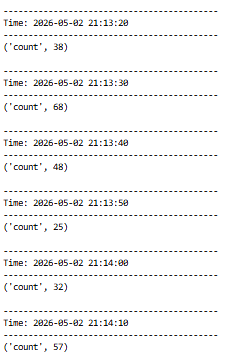

#### Exercici 10.2: Comptant Toots per Idioma (0.4 punts)

Com has observat a l'Exercici 2.1, el procés és bastant similar a treballar amb RDDs. 
Ara, aprofundirem en una anàlisi més complexa **comptant quants toots originals es creen 
per idioma cada 10 segons**. Per millorar la llegibilitat, et demanem que ordenïs 
els idiomes en ordre descendent segons el nombre de toots i limitïs la sortida als 5 principals idiomes.

In [24]:
import findspark
findspark.init()

from pyspark import SparkContext
from pyspark.streaming import StreamingContext
import json

# Initialize SparkContext and StreamingContext with a 10-second batch interval
app_name = "exercici_10_2_toots_per_idioma"  # Name of your application

# Create the SparkContext
try:
    sc = SparkContext("local[*]", appName = app_name)
except ValueError:
    sc.stop()
    sc = SparkContext("local[*]", appName = app_name)
sc.setLogLevel("ERROR")

# Create the StreamingContext
batch_interval = 10  # Batch interval in seconds
ssc = StreamingContext(sc, batch_interval)
ssc.checkpoint("checkpoint_10_2")  # Necessary for updateStateByKey operation

# Define stream parameters
socket_host = "localhost"  # or IP / localhost
socket_port = 9999

kafkaStream = ssc.socketTextStream(socket_host, socket_port)

# Count the number of toots per language
# Comptem el nombre de toots originals per idioma.
tootLangCounts = (
    kafkaStream

    # Convertim cada línia rebuda pel socket en un diccionari Python.
    .map(lambda x: json.loads(x.strip()))

    # Ens quedem només amb els toots originals.
    # Si "reblog" és None, no és un retoot.
    .filter(lambda toot: toot.get("reblog") is None)

    # Eliminem els toots sense idioma informat.
    .filter(lambda toot: toot.get("language") is not None)

    # Creem parelles (idioma, 1).
    .map(lambda toot: (toot.get("language"), 1))

    # Sumem els toots de cada idioma dins del batch actual.
    .reduceByKey(lambda a, b: a + b)

    # Ordenem de més a menys segons el recompte.
    .transform(lambda rdd: rdd.sortBy(lambda x: x[1], ascending=False))
)


# Print the cumulative count
tootLangCounts.pprint(5)

# Start the computation
try:
    ssc.start()
    ssc.awaitTermination()
except KeyboardInterrupt:
    ssc.stop()
    sc.stop()

Py4JJavaError: An error occurred while calling o1269.start.
: java.lang.IllegalStateException: Only one StreamingContext may be started in this JVM. Currently running StreamingContext was started atorg.apache.spark.streaming.api.java.JavaStreamingContext.start(JavaStreamingContext.scala:557)
java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)
java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke(NativeMethodAccessorImpl.java:77)
java.base/jdk.internal.reflect.DelegatingMethodAccessorImpl.invoke(DelegatingMethodAccessorImpl.java:43)
java.base/java.lang.reflect.Method.invoke(Method.java:569)
py4j.reflection.MethodInvoker.invoke(MethodInvoker.java:244)
py4j.reflection.ReflectionEngine.invoke(ReflectionEngine.java:357)
py4j.Gateway.invoke(Gateway.java:282)
py4j.commands.AbstractCommand.invokeMethod(AbstractCommand.java:132)
py4j.commands.CallCommand.execute(CallCommand.java:79)
py4j.ClientServerConnection.waitForCommands(ClientServerConnection.java:182)


Afegeix la captura de pantalla del resultat **aquí**
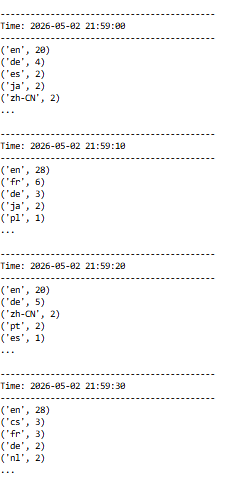

#### Exercici 10.3: Mantenint el Recompte (0.4 punts)


Fins ara, hem estat obtenint resultats específics de lots, cosa que generalment és útil. 
Però, què passa si vols obtenir una visió més àmplia, mantenint la informació a través de les 
finestres per, per exemple, acumular tendències al llarg del temps? 
Aquest és l'enfocament de la nostra propera exploració.

En aquest exercici, t'invitem a modificar l'script anterior per **mantenir un recompte acumulat de tots els toots originals, categoritzats per idioma**. En lloc de simplement comptar nous toots cada cinc segons, anem a **sumar-los contínuament**. Pensa-hi com un marcador que s'actualitza constantment amb el nombre total de toots originals en cada idioma des del moment en què vam començar a fer streaming.

Per aconseguir-ho, treballarem amb les transformacions 
[**stateful transformations in Spark Streaming**](https://downloads.apache.org/spark/docs/3.3.0/streaming-programming-guide.html#caching--persistence).
Aquesta és una forma sofisticada de dir que recordarem les dades passades i les utilitzarem 
en els nostres càlculs actuals. És similar a mantenir un total acumulat en una variable 
global en lloc de començar des de zero cada vegada.

**T'invitem a completar el següent script:**

In [ ]:
import findspark
findspark.init()

from pyspark import SparkContext
from pyspark.streaming import StreamingContext
import json

# Initialize SparkContext and StreamingContext with a 10-second batch interval
app_name = "exercici_10_3_recompte_acumulat_idioma" # Name of your application

# Create the SparkContext
try:
    sc = SparkContext("local[*]", appName=app_name) # MODIFICAT
except ValueError:
    sc.stop()
    sc = SparkContext("local[*]", appName=app_name) # MODIFICAT

sc.setLogLevel("ERROR")

batch_interval = 10  # Batch interval in seconds
ssc = StreamingContext(sc, batch_interval)
ssc.checkpoint("checkpoint_10_3")  # Necessary for updateStateByKey operation

# Define stream parameters
socket_host = "localhost"  # or IP / localhost
socket_port = 9999

kafkaStream = ssc.socketTextStream(socket_host, socket_port)

# Update the cumulative count using updateStateByKey
# Funció que actualitza el recompte acumulat.
def updateFunction(newValues, runningCount):
    # Si encara no hi ha recompte acumulat, comencem des de 0.
    if runningCount is None:
        runningCount = 0
    
    # Sumem els valors nous del batch al recompte anterior.
    return sum(newValues) + runningCount

# Count each toot as 1 and update the total count
# Comptem els toots originals per idioma i mantenim el recompte acumulat.
tootCounts = (
    kafkaStream

    # Convertim cada línia JSON rebuda pel socket en un diccionari Python.
    .map(lambda x: json.loads(x.strip()))

    # Ens quedem només amb els toots originals.
    .filter(lambda toot: toot.get("reblog") is None)

    # Eliminem els toots que no tenen idioma informat.
    .filter(lambda toot: toot.get("language") is not None)

    # Creem parelles (idioma, 1).
    .map(lambda toot: (toot.get("language"), 1))

    # Actualitzem el recompte acumulat per idioma entre batches.
    .updateStateByKey(updateFunction)

    # Ordenem de més a menys segons el recompte acumulat.
    .transform(lambda rdd: rdd.sortBy(lambda x: x[1], ascending=False))
)

# Print the cumulative count
tootCounts.pprint()

# Start the computation
try:
    ssc.start()
    ssc.awaitTermination()
except KeyboardInterrupt:
    ssc.stop()
    sc.stop()

Afegeix la captura de pantalla del resultat **aquí**
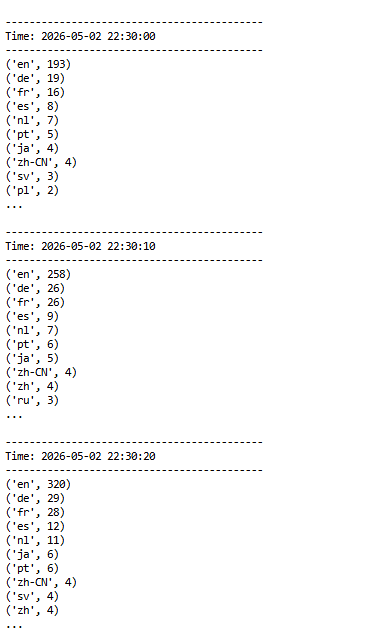

#### Exercici 10.4: Windowed Counting (0.5 punts)

Com has observat, Spark Streaming és increïblement flexible i 
fàcil d'usar, i aquí tens un truc interessant que pot realitzar: 
**et permet trobar un punt intermedi entre comptar toots en una [time
window](https://downloads.apache.org/spark/docs/3.3.0/streaming-programming-guide.html#window-operations)
i mantenir un total acumulat**. Imaginem que volem crear un panell de control, 
com un tauler, que mostri el nombre de toots realitzats en cada idioma. 
El gir és que **volem que aquesta actualització es produeixi cada 5 segons, 
però estem rastrejant els recomptes durant un minut complet**.

Així, cada 5 segons, el nostre panell s'actualitza, proporcionant-nos 
el darrer recompte acumulat durant un minut. És com tenir un marcador en viu 
que s'actualitza amb freqüència i també realitza un seguiment del que ha ocorregut 
en els darrers 60 segons, no només en els darrers 5. D'aquesta manera, obtens 
tant actualitzacions immediates com una vista més àmplia del que està ocorrent, 
tot al mateix temps. Mostra només els 10 principals idiomes.

**Modifica el següent script per aconseguir aquest objectiu:**


In [ ]:
import findspark
findspark.init()

from pyspark import SparkContext
from pyspark.streaming import StreamingContext
import json

# Initialize SparkContext and StreamingContext with a 1-second batch interval
app_name = "exercici_10_4_windowed_counting"  # Name of your application

# Create the SparkContext
try:
    sc = SparkContext("local[*]", appName=app_name) # MODIFICAT
except ValueError:
    sc.stop()
    sc = SparkContext("local[*]", appName=app_name) # MODIFICAT

sc.setLogLevel("ERROR")

# Fem batches de 5 segons perquè la finestra s'actualitza cada 5 segons.
batch_interval = 5
ssc = StreamingContext(sc, batch_interval)
ssc.checkpoint("checkpoint_10_4")  # Necessary for updateStateByKey operation

# Define stream parameters
socket_host = "localhost"  # or IP / localhost
socket_port = 9999

kafkaStream = ssc.socketTextStream(socket_host, socket_port)

# Count each toot as 1 and update the total count. Use a 60-second window with a 5-second slide
# Comptem els toots originals per idioma dins d'una finestra temporal.
tootCounts = (
    kafkaStream

    # Convertim cada línia JSON rebuda pel socket en un diccionari Python.
    .map(lambda x: json.loads(x.strip()))

    # Ens quedem només amb els toots originals.
    .filter(lambda toot: toot.get("reblog") is None)

    # Eliminem els toots sense idioma informat.
    .filter(lambda toot: toot.get("language") is not None)

    # Creem parelles (idioma, 1).
    .map(lambda toot: (toot.get("language"), 1))

    # Comptem per idioma dins dels darrers 60 segons,
    # actualitzant el resultat cada 5 segons.
    .reduceByKeyAndWindow(
        lambda a, b: a + b,   # Sumem els nous valors que entren a la finestra.
        lambda a, b: a - b,   # Restem els valors antics que surten de la finestra.
        60,                   # Durada de la finestra: 60 segons.
        5                     # Actualització cada 5 segons.
    )

    # Ordenem de més a menys segons el recompte de la finestra.
    .transform(lambda rdd: rdd.sortBy(lambda x: x[1], ascending=False))
)

# Print the cumulative count
# Mostrem només els 10 idiomes principals.
tootCounts.pprint(10)

# Start the computation
try:
    ssc.start()
    ssc.awaitTermination()
except KeyboardInterrupt:
    ssc.stop()
    sc.stop()

Afegeix la captura de pantalla del resultat **aquí**
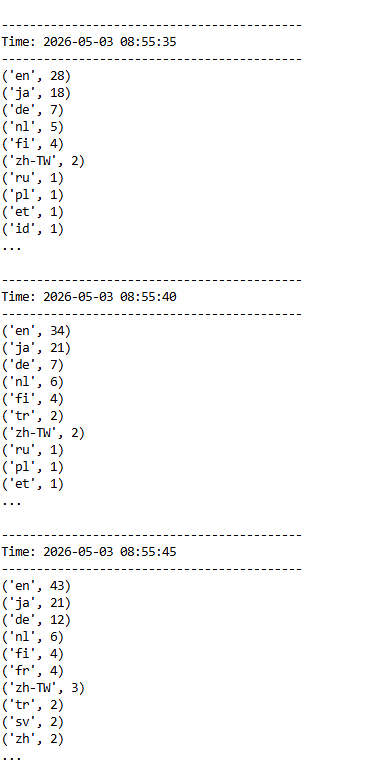

### Exercici 10.5: Powering Up (1 punt)


Molt bé, ja sabem que els RDDs en Spark són increïblement versàtils: 
són com la navalla suïssa del processament de dades d'stream. Pots fer pràcticament 
qualsevol operació amb ells. Tanmateix, **a mesura que les coses es tornen més complexes, 
el repte augmenta.**

Ara, anem a fer el nostre panell de control encara més interessant. En lloc de només mostrar 
quants toots tenim per minut, afegim algunes característiques noves. 
No seria interessant **rastrejar la longitud mitjana d'aquests toots?**
I hi ha més: anem a descobrir **qui és l'usuari amb més seguidors entre els que han tootejat en aquell minut.**

Espera, **¡hi ha més!** Per fer tota aquesta informació súper fàcil de llegir i entendre, la presentarem en un format de taula ordenat i net. No es tracta només de les dades, sinó de fer-les amigables per a l'usuari i visualment digeribles.

La taula resultant s'ha d'actualitzar en intervals de 5 segons, i les finestres de mitjana han de ser de 60 segons. Les columnes d'aquesta taula han de ser:
    
-   **`lang`:** Idioma
-   **`num_toots`:** Nombre de toots originals en aquell idioma
-   **`avg_len_content`:** Longitud mitjana (en caràcters) del contingut del toot
-   **`user`:** Usuari amb més seguidors
-   **`followers`:** Nombre de seguidors d'aquest usuari

Per fer la sortida més llegible, limita el nombre de files a 10.

**TIP:** Hi ha un exemple molt útil a [Spark Streaming](https://downloads.apache.org/spark/docs/3.3.0/streaming-programming-guide.html#dataframe-and-sql-operations). Busca'l!


In [ ]:
import findspark
findspark.init()

from pyspark import SparkContext
from pyspark.streaming import StreamingContext
from pyspark.sql import SparkSession, Row

import json
import re
import html

# Objectiu:
# Crear una taula resum que s'actualitzi cada 5 segons.
#
# La taula ha de calcular informació sobre els toots originals rebuts
# durant una finestra temporal de 60 segons.
#
# Columnes demanades:
# - lang: idioma
# - num_toots: nombre de toots originals en aquell idioma
# - avg_len_content: longitud mitjana del contingut del toot
# - user: usuari amb més seguidors dins d'aquell idioma
# - followers: nombre de seguidors d'aquest usuari
# -------------------------------------------------------------------


# Nom de l'aplicació Spark.
app_name = "exercici_10_5_powering_up"


# -------------------------------------------------------------------
# Creació del SparkContext
# -------------------------------------------------------------------
# SparkContext és el punt d'entrada principal de Spark.
# Fem servir local[*] perquè Spark utilitzi tots els nuclis disponibles.
try:
    sc = SparkContext("local[*]", appName=app_name)

except ValueError:
    # Si ja hi hagués un SparkContext actiu, l'aturem i en creem un de nou.
    sc.stop()
    sc = SparkContext("local[*]", appName=app_name)


# Reduïm els missatges de log perquè la sortida sigui més llegible.
sc.setLogLevel("ERROR")


# -------------------------------------------------------------------
# Creació del StreamingContext
# -------------------------------------------------------------------
# L'enunciat demana que la taula s'actualitzi cada 5 segons.
# Per això fem servir un batch interval de 5 segons.
batch_interval = 5

# StreamingContext és el punt d'entrada de Spark Streaming.
ssc = StreamingContext(sc, batch_interval)


# Definim un directori de checkpoint.
# És recomanable en operacions amb finestra perquè Spark pot necessitar
# guardar informació intermèdia del càlcul.
ssc.checkpoint("checkpoint_10_5")


# -------------------------------------------------------------------
# Definició del flux d'entrada
# -------------------------------------------------------------------
# El flux de Mastodon està disponible al clúster a través del socket.
socket_host = "localhost"
socket_port = 9999

# Creem un DStream que llegeix línies de text del socket.
# Cada línia rebuda és un JSON en format text.
kafkaStream = ssc.socketTextStream(socket_host, socket_port)


# -------------------------------------------------------------------
# SparkSession reutilitzable
# -------------------------------------------------------------------
# L'exemple del document de Spark Streaming recomana crear una
# SparkSession de manera reutilitzable dins de foreachRDD().
#
# SparkSession ens permet treballar amb DataFrames i SQL.
def getSparkSessionInstance(sparkConf):

    # Comprovem si ja existeix una SparkSession global.
    if "sparkSessionSingletonInstance" not in globals():

        # Si no existeix, la creem a partir de la configuració de Spark.
        globals()["sparkSessionSingletonInstance"] = SparkSession \
            .builder \
            .config(conf=sparkConf) \
            .getOrCreate()

    # Retornem la SparkSession existent o acabada de crear.
    return globals()["sparkSessionSingletonInstance"]


# -------------------------------------------------------------------
# Funció per netejar el text del toot
# -------------------------------------------------------------------
# El camp "content" de Mastodon pot contenir HTML.
# Per exemple: <p>text</p>, &amp;, &quot;, etc.
#
# Aquesta funció elimina les etiquetes HTML i converteix entitats HTML
# a text normal.
def clean_text(content):

    # Eliminem etiquetes HTML com <p>, <br>, <a>, etc.
    text = re.sub("<[^>]+>", "", content)

    # Convertim entitats HTML com &amp; en &, &quot; en ", etc.
    text = html.unescape(text)

    # Retornem el text net.
    return text


# -------------------------------------------------------------------
# Funció per interpretar cada toot
# -------------------------------------------------------------------
# Aquesta funció rep una línia JSON en format text.
# La converteix en diccionari Python i extreu només els camps necessaris.
#
# Si el toot no és vàlid, no és original o no té idioma, retornem None.
def parse_toot(x):

    try:
        # Convertim la línia rebuda pel socket en un diccionari Python.
        toot = json.loads(x.strip())

        # L'enunciat demana només toots originals.
        # Si "reblog" no és None, vol dir que és un retoot.
        if toot.get("reblog") is not None:
            return None

        # Recuperem l'idioma del toot.
        lang = toot.get("language")

        # Si no hi ha idioma, descartem el registre.
        if lang is None:
            return None

        # Recuperem el contingut del toot.
        # En Mastodon normalment és "content", però deixem "text"
        # com a alternativa per seguretat.
        content = toot.get("content") or toot.get("text") or ""

        # Netegem el contingut HTML.
        content = clean_text(content)

        # Calculem la longitud del contingut en caràcters.
        content_len = len(content)

        # Recuperem la informació de l'usuari.
        # En Mastodon normalment el camp és "account".
        account = toot.get("account") or toot.get("user") or {}

        # Recuperem el nom d'usuari.
        # Provem diversos camps possibles i, si no n'hi ha cap,
        # assignem "unknown".
        user = (
            account.get("acct")
            or account.get("username")
            or account.get("display_name")
            or "unknown"
        )

        # Recuperem el nombre de seguidors.
        followers = account.get("followers_count") or 0

        # Convertim els seguidors a enter.
        followers = int(followers)

        # Retornem una Row.
        # Aquesta Row serà una fila del futur DataFrame.
        return Row(
            lang=lang,
            content_len=content_len,
            user=user,
            followers=followers
        )

    except Exception:
        # Si algun registre ve mal format o no es pot processar,
        # el descartem retornant None.
        return None


# -------------------------------------------------------------------
# Funció per processar cada RDD de la finestra
# -------------------------------------------------------------------
# Aquesta funció s'executa a cada actualització de la finestra.
#
# Rep:
# - time: instant temporal del batch
# - rdd: dades de la finestra actual
#
# Dins d'aquesta funció convertim l'RDD en DataFrame i fem SQL.
def process(time, rdd):

    # Mostrem el temps del batch per identificar cada sortida.
    print("\n========= %s =========" % str(time))

    # Si l'RDD està buit, no podem crear cap DataFrame.
    if rdd.isEmpty():
        print("No hi ha dades en aquesta finestra.")
        return

    try:
        # Obtenim o creem la SparkSession.
        spark = getSparkSessionInstance(rdd.context.getConf())

        # Convertim l'RDD de Row en un DataFrame.
        # El DataFrame tindrà les columnes:
        # lang, content_len, user, followers.
        tootsDataFrame = spark.createDataFrame(rdd)

        # Creem una vista temporal anomenada "toots".
        # Això ens permet escriure consultes SQL sobre el DataFrame.
        tootsDataFrame.createOrReplaceTempView("toots")

        # Consulta SQL:
        #
        # 1. aggregated:
        #    Agrupa per idioma i calcula:
        #    - nombre de toots
        #    - longitud mitjana del contingut
        #
        # 2. ranked_users:
        #    Ordena els usuaris de cada idioma segons el nombre de seguidors.
        #    ROW_NUMBER() assigna rn = 1 a l'usuari amb més seguidors.
        #
        # 3. Consulta final:
        #    Uneix les mètriques agregades amb l'usuari més seguit.
        #    Ordena per nombre de toots i limita la sortida a 10 files.
        resultDataFrame = spark.sql("""
            WITH aggregated AS (
                SELECT
                    lang,
                    COUNT(*) AS num_toots,
                    ROUND(AVG(content_len), 2) AS avg_len_content
                FROM toots
                GROUP BY lang
            ),
            ranked_users AS (
                SELECT
                    lang,
                    `user`,
                    followers,
                    ROW_NUMBER() OVER (
                        PARTITION BY lang
                        ORDER BY followers DESC, `user` ASC
                    ) AS rn
                FROM toots
            )
            SELECT
                a.lang,
                a.num_toots,
                a.avg_len_content,
                r.`user`,
                r.followers
            FROM aggregated a
            JOIN ranked_users r
                ON a.lang = r.lang
            WHERE r.rn = 1
            ORDER BY a.num_toots DESC, a.lang ASC
            LIMIT 10
        """)

        # Mostrem la taula final.
        # truncate=False evita que Spark retalli noms d'usuari llargs.
        resultDataFrame.show(10, truncate=False)

    except Exception as e:
        # Si hi ha algun problema en aquesta finestra,
        # mostrem l'error però no aturem tota l'aplicació.
        print("Error processant aquesta finestra:", e)


# -------------------------------------------------------------------
# Construcció del flux principal
# -------------------------------------------------------------------
# Ara definim les transformacions sobre el DStream.
tootRows = (
    kafkaStream

    # Convertim cada línia JSON en una Row amb les dades necessàries.
    .map(parse_toot)

    # Eliminem els registres descartats per parse_toot().
    .filter(lambda x: x is not None)

    # Apliquem una finestra de 60 segons.
    # El segon paràmetre indica que s'actualitza cada 5 segons.
    .window(60, 5)
)


# -------------------------------------------------------------------
# Sortida del flux
# -------------------------------------------------------------------
# foreachRDD aplica la funció process() a cada RDD generat pel DStream.
# És aquí on es força l'execució del flux i es mostra la taula.
tootRows.foreachRDD(process)


# -------------------------------------------------------------------
# Execució de Spark Streaming
# -------------------------------------------------------------------
try:
    # Iniciem el procés de streaming.
    ssc.start()

    # Mantenim l'aplicació en execució fins que l'aturem manualment.
    ssc.awaitTermination()

except KeyboardInterrupt:
    # Si aturem amb CTRL + C, tanquem StreamingContext i SparkContext.
    ssc.stop()
    sc.stop()

Afegeix la captura de pantalla del resultat **aquí** 
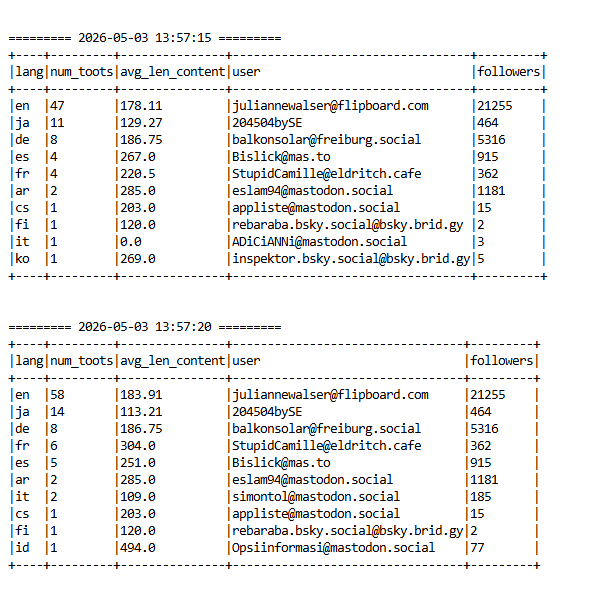

## Exercici 11: Structured Streaming (2.6 punts)

Com has vist en l'últim exercici, depenent de les operacions, 
l'API de Spark Streaming pot no resultar tan convenient, 
especialment perquè has de tractar amb APIs de baix nivell. Afortunadament, **Spark provides a
high-level API called [Spark Structured
Streaming](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html)** que et permet **expressar els càlculs d'streaming de la mateixa manera que expressaries un càlcul per lots sobre dades estructurades estàtiques**, com les que usaries en el processament per lots.

En aquest conjunt d'exercicis, et submergirás en el fascinant món de Spark Structured Streaming.

## Exercici 11.1: Getting the Schema (0.3 punts)

Una de les característiques més interessants de Spark Structured Streaming és 
**com gestiona les dades estructurades**. Per exemple, el flux de dades en el nostre tema de Kafka, 
on **cada "toot" arriba en un format JSON ordenat**, cosa que el fa estructurat i organitzat.

De manera similar a com es treballa amb DataFrames a Spark, **Structured Streaming usa esquemes de dades per analitzar dades estructurades**, essencialment un plànol de com estan disposades les dades. Per al processament per lots, Spark pot sovint deduir aquesta estructura directament de les dades. Tanmateix, amb les dades d'streaming, és una mica diferent: **hem de definir aquesta estructura prèviament.**

En els exercicis següents, utilitzarem un truc convenient: **en lloc de definir manualment**
l'estructura complexa d'un "toot", inicialment **extraurem alguns toots de Kafka i els analitzarem en un lot per aprendre el seu esquema**. És com fer un cop d'ull per entendre com estan organitzades les coses. 
Un cop tinguem l'esquema, l'aplicarem a la nostra pipeline d'streaming.

La teva tasca en aquest exercici és realitzar aquesta transformació. Després, utilitzant les operacions de DataFrame amb les quals ja estàs familiaritzat, crearàs una taula amb les columnes següents que ens permetrà veure els toots individualment a mesura que es processen:


-   **`id`:** Identificador únic per a cada toot
-   **`created_at`:** Data i hora en què es va crear el toot
-   **`content`:** El contingut del toot
-   **`language`:** L'idioma del toot
-   **`username`:** El nom d'usuari de l'autor del toot
-   **`followers_count`:** Nombre de seguidors de l'autor.


Recorda que ens **interessen els toots originals**. Filtra els que són retweets.

Un altre aspecte fonamental que has de gestionar aquí és **seleccionar el outputMode adequat**. Consulta 
[la documentació](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#output-modes)
i tria el que millor s'adapti a aquest exercici.


In [ ]:
# ------------------------------------------------------------
# Inicialització de findspark
# ------------------------------------------------------------
# findspark permet que Python localitzi correctament la instal·lació
# de Spark dins de l'entorn del clúster.
# És habitual utilitzar-lo en entorns Jupyter o en entorns on Spark
# no està directament configurat al PYTHONPATH.
import findspark
findspark.init()


# ------------------------------------------------------------
# Importació de llibreries de PySpark
# ------------------------------------------------------------
# SparkSession és el punt d'entrada principal per treballar amb
# DataFrames i Structured Streaming.
from pyspark.sql import SparkSession

# SparkConf i SparkContext permeten configurar i inicialitzar Spark.
from pyspark import SparkConf, SparkContext

# from_json permet convertir una cadena JSON en una estructura Spark.
# col permet referenciar columnes del DataFrame.
from pyspark.sql.functions import from_json, col


# ------------------------------------------------------------
# Configuració bàsica de Spark
# ------------------------------------------------------------
# Creem una configuració de Spark.
conf = SparkConf()

# Treballem en mode local utilitzant tots els nuclis disponibles.
# local[*] indica que Spark pot utilitzar tots els cores de la màquina.
conf.setMaster("local[*]")

# Creem el SparkContext, que és el context base de Spark.
# En aquest script només en creem un.
sc = SparkContext(conf=conf)

# Reduïm el nivell de logs per evitar que la sortida sigui massa extensa.
# Això fa que no apareguin tants missatges INFO durant l'execució.
sc.setLogLevel("ERROR")


# ------------------------------------------------------------
# Creació de la SparkSession
# ------------------------------------------------------------
# SparkSession és necessària per treballar amb DataFrames,
# llegir dades de Kafka amb readStream i aplicar Structured Streaming.
#
# L'enunciat indica que el nom de l'aplicació ha d'incloure
# els usuaris dels membres del grup.
app_name = "activity3_1_jbaigesf_mserrar"

spark = SparkSession \
    .builder \
    .appName(app_name) \
    .getOrCreate()


# ------------------------------------------------------------
# Paràmetres de connexió a Kafka
# ------------------------------------------------------------
# Aquest és el servidor Kafka del clúster de la pràctica.
kafka_bootstrap_servers = "eimtcld3node1:9092"

# Topic que conté els missatges JSON dels toots de Mastodon.
# Aquest topic l'hem comprovat prèviament amb kafka-console-consumer.sh.
kafka_topic = "mastodon_toots"


# ------------------------------------------------------------
# Lectura batch petita per inferir l'esquema JSON
# ------------------------------------------------------------
# Structured Streaming necessita conèixer l'esquema de les dades
# abans de poder aplicar from_json() sobre el flux.
#
# Com que els missatges de Kafka són JSONs dins de la columna value,
# fem primer una lectura batch petita del topic per inferir-ne l'esquema.
#
# Important:
# - startingOffsets="earliest" indica que, per a aquesta lectura batch,
#   comencem pel primer offset disponible actualment.
# - endingOffsets="latest" indica que llegim fins a l'últim offset disponible.
# - limit(10) evita processar massa missatges només per inferir l'esquema.
#
# Aquesta lectura només serveix per obtenir l'esquema. No és la lectura
# streaming principal de l'exercici.
batch_df = spark \
    .read \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "earliest") \
    .option("endingOffsets", "latest") \
    .load() \
    .limit(10)


# ------------------------------------------------------------
# Inferència de l'esquema JSON
# ------------------------------------------------------------
# Kafka desa el contingut del missatge a la columna value.
# Aquesta columna és de tipus binari, per això primer la convertim a string.
#
# La línia següent és la de la plantilla:
# 1. Selecciona value convertit a string.
# 2. Converteix el DataFrame a RDD.
# 3. Extreu el text JSON de cada fila.
# 4. Fa que Spark infereixi automàticament l'esquema JSON.
schema = spark.read.json(
    batch_df
    .selectExpr("CAST(value AS STRING)")
    .rdd
    .map(lambda x: x[0])
).schema

# Mostrem l'esquema inferit per pantalla.
# Això ens permet comprovar que Spark ha detectat camps com:
# account, content, created_at, language, reblog, etc.
print(schema.simpleString())


# ------------------------------------------------------------
# Lectura streaming des de Kafka
# ------------------------------------------------------------
# Ara sí que definim la lectura en streaming.
# Aquesta lectura queda activa i va processant nous missatges del topic.
#
# Fem servir startingOffsets="latest" perquè el topic conté molts missatges
# històrics i llegir-los tots podia provocar problemes de memòria.
#
# maxOffsetsPerTrigger limita el nombre màxim de missatges processats
# en cada microbatch. Això ajuda a controlar la càrrega de treball i evita
# que Spark intenti processar massa dades de cop.
toots = spark \
    .readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "latest") \
    .option("maxOffsetsPerTrigger", 5) \
    .load()


# ------------------------------------------------------------
# Parseig del JSON i selecció de columnes
# ------------------------------------------------------------
# El DataFrame streaming original de Kafka conté columnes com:
# key, value, topic, partition, offset i timestamp.
#
# La informació real del toot és dins de value.
# Per això:
# 1. Convertim value a string.
# 2. Apliquem from_json() utilitzant l'esquema inferit.
# 3. Guardem el resultat en una columna estructurada anomenada parsed_value.
# 4. Filtrem només els toots originals.
# 5. Seleccionem les columnes que demana l'enunciat.
toots_df = (
    toots

    # Convertim el camp value de Kafka a string i el parsegem com a JSON.
    # El resultat és una estructura Spark amb els camps del toot.
    .select(
        from_json(
            col("value").cast("string"),
            schema
        ).alias("parsed_value")
    )

    # Ens quedem només amb els toots originals.
    # En Mastodon, el camp reblog indica si el toot és un retoot.
    # - Si reblog és null, el missatge és un toot original.
    # - Si reblog conté una estructura, el missatge és un retoot.
    .filter(col("parsed_value.reblog").isNull())

    # Seleccionem les columnes demanades per l'enunciat.
    # account.username conté el nom d'usuari.
    # account.followers_count conté el nombre de seguidors de l'usuari.
    .select(
        col("parsed_value.id").alias("id"),
        col("parsed_value.created_at").alias("created_at"),
        col("parsed_value.content").alias("content"),
        col("parsed_value.language").alias("language"),
        col("parsed_value.account.username").alias("username"),
        col("parsed_value.account.followers_count").alias("followers_count")
    )
)


# ------------------------------------------------------------
# Sortida del flux per consola
# ------------------------------------------------------------
# Com que aquesta consulta no fa cap agregació, ni manté estat,
# ni actualitza files anteriors, el mode de sortida adequat és append.
#
# append vol dir que Spark només mostra les noves files que arriben
# en cada microbatch.
#
# En aquest exercici no utilitzem checkpointLocation perquè la consulta
# és simple: només parseja, filtra i selecciona columnes.
try:
    query = (
        toots_df
        .writeStream

        # Mode append: només s'escriuen les noves files processades.
        .outputMode("append")

        # Mostrem els resultats per consola.
        .format("console")

        # truncate=true evita imprimir continguts HTML molt llargs sencers.
        # El camp content pot contenir etiquetes HTML i textos llargs.
        .option("truncate", "true")

        # Mostrem com a màxim 10 files per microbatch.
        .option("numRows", 10)

        # Definim que la consulta s'executi cada 10 segons.
        # Cada 10 segons Spark crea un nou microbatch.
        .trigger(processingTime="10 seconds")

        # Iniciem la consulta streaming.
        .start()
    )

    # Mantenim la consulta activa fins que l'aturem manualment.
    # En una aplicació streaming això és normal: el programa no acaba sol.
    query.awaitTermination()

except KeyboardInterrupt:
    # Si aturem l'execució amb CTRL + C, tanquem correctament
    # la consulta streaming, la SparkSession i el SparkContext.
    query.stop()
    spark.stop()
    sc.stop()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<strong>Exercici 11.1: Obtenció de l'esquema i lectura del flux de Kafka</strong><br><br>

En aquest apartat treballem amb <strong>Spark Structured Streaming</strong> per llegir dades en temps real des d'un topic de Kafka que conté missatges de Mastodon en format JSON.<br><br>

L'objectiu principal és construir un DataFrame de streaming amb les columnes demanades per l'enunciat: <code>id</code>, <code>created_at</code>, <code>content</code>, <code>language</code>, <code>username</code> i <code>followers_count</code>.<br><br>

Com que els missatges de Kafka arriben dins de la columna <code>value</code> en format binari, primer necessitem convertir aquest camp a text i interpretar-lo com un JSON. Per fer-ho, llegim inicialment una petita mostra del topic en mode batch i inferim l'esquema amb <code>spark.read.json()</code>.<br><br>

Després utilitzem aquest esquema dins del flux amb <code>from_json()</code>, de manera que Spark pot transformar cada missatge rebut en una estructura amb camps accessibles com <code>parsed_value.id</code>, <code>parsed_value.content</code> o <code>parsed_value.account.username</code>.<br><br>

També filtrem els retoots amb la condició <code>reblog IS NULL</code>. En Mastodon, quan el camp <code>reblog</code> és nul, el missatge correspon a un toot original; en canvi, quan conté una estructura, correspon a un retoot.<br><br>

Finalment, escrivim la sortida per consola amb <code>outputMode("append")</code>, ja que aquesta consulta no fa cap agregació ni manté estat: cada toot original processat genera una nova fila independent.

</div>

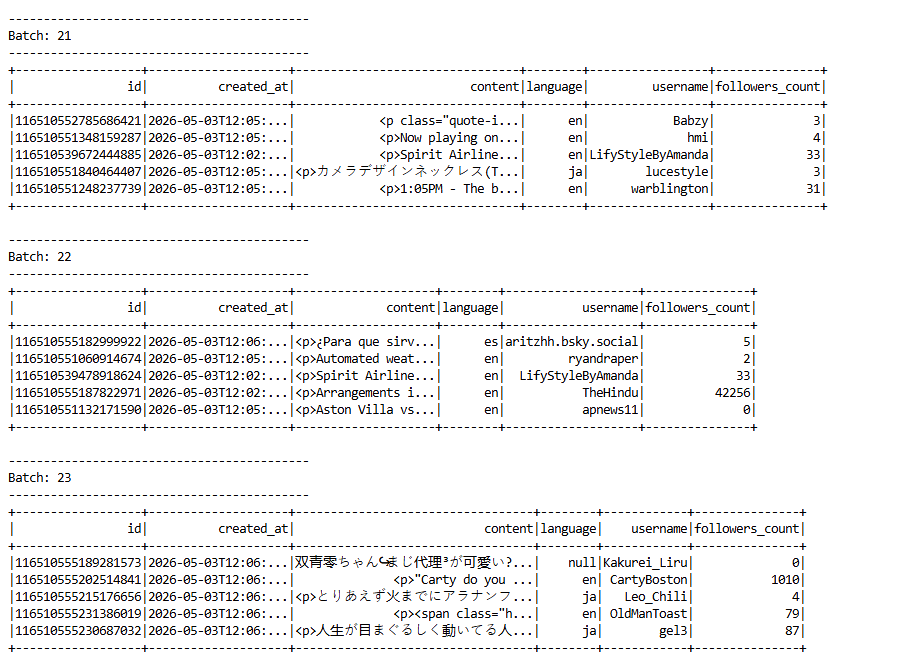

### Exercici 11.2: Agregant Dades des d'un Flux (0.3 punts)

Spark Structured Streaming és realment poderós, especialment quan es realitzen operacions sobre un flux continu de dades. En aquest exercici, aprofundirem en Structured Spark Streaming, centrant-nos específicament en l'agregació de dades des d'un flux de Kafka. És similar al que vam fer a l'Exercici 2. La teva missió és **comptar el nombre de toots originals en cada idioma.**

Aquí et mostrem com ha de ser la teva sortida:

-   **`language`:** Aquesta columna mostra l'idioma dels toots.
-   **`count`:** Aquí és on mostraràs el nombre de toots per cada idioma.

La teva taula ha d'**acumular aquests recomptes cada 10 segons, i també ha de continuar acumulant-los**. A més, fes-la amigable per a l'usuari **ordenant els idiomes pel nombre de toots, amb els idiomes més parladors a la part superior.**

Ara, aquí hi ha una **part clau** d'aquest exercici: **has de triar el mode de sortida adequat per a la teva consulta d'streaming**. Recorda, el **mode de sortida determina com s'escriu cada lot de dades resultant al destí de sortida**. Les teves opcions són els modes 'Complete', 'Append' i 'Update'. Pensa quin encaixa millor per al nostre escenari de recompte acumulatiu i ordenat. I **no oblidis escriure el teu raonament als comentaris.**


In [ ]:
# ------------------------------------------------------------
# Inicialització de findspark
# ------------------------------------------------------------
# findspark permet que Python localitzi correctament la instal·lació
# de Spark dins de l'entorn del clúster.
import findspark
findspark.init()


# ------------------------------------------------------------
# Importació de llibreries
# ------------------------------------------------------------
from pyspark.sql import SparkSession
from pyspark import SparkConf, SparkContext

# from_json permet interpretar el JSON del camp value de Kafka.
# col permet seleccionar columnes.
from pyspark.sql.functions import from_json, col


# ------------------------------------------------------------
# Configuració de Spark
# ------------------------------------------------------------
conf = SparkConf()
conf.setMaster("local[*]")

sc = SparkContext(conf=conf)

# Reduïm el nivell de logs per facilitar la lectura de la sortida.
sc.setLogLevel("ERROR")


# ------------------------------------------------------------
# Creació de la SparkSession
# ------------------------------------------------------------
# El nom de l'aplicació ha d'incloure els usuaris del grup.
app_name = "activity3_2_jbaigesf_mserrar"

spark = SparkSession \
    .builder \
    .appName(app_name) \
    .getOrCreate()


# ------------------------------------------------------------
# Paràmetres de Kafka
# ------------------------------------------------------------
# Broker Kafka del clúster de la pràctica.
kafka_bootstrap_servers = "eimtcld3node1:9092"

# Topic que conté els JSONs dels toots de Mastodon.
kafka_topic = "mastodon_toots"


# ------------------------------------------------------------
# Lectura batch petita per inferir l'esquema
# ------------------------------------------------------------
# Structured Streaming necessita conèixer l'esquema abans de processar
# el flux. Per això llegim uns quants missatges en mode batch.
#
# Important:
# A la plantilla apareixia endingOffsets amb l'offset absolut 10.
# Al nostre entorn això provocava error perquè els offsets antics ja
# no estaven disponibles. Per això fem servir endingOffsets="latest"
# i després limitem la mostra amb limit(10).
batch_df = spark \
    .read \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "earliest") \
    .option("endingOffsets", "latest") \
    .load() \
    .limit(10)


# ------------------------------------------------------------
# Inferència de l'esquema JSON
# ------------------------------------------------------------
# Kafka desa el missatge dins la columna value en format binari.
# Primer convertim value a string i després Spark infereix l'esquema JSON.
schema = spark.read.json(
    batch_df
    .selectExpr("CAST(value AS STRING)")
    .rdd
    .map(lambda x: x[0])
).schema

# Mostrem l'esquema per comprovar que s'ha inferit correctament.
print(schema.simpleString())


# ------------------------------------------------------------
# Lectura streaming des de Kafka
# ------------------------------------------------------------
# Llegim el topic de Kafka en mode streaming.
#
# Fem servir startingOffsets="latest" per evitar carregar tot l'històric
# del topic, que és molt gran i pot provocar problemes de memòria.
#
# maxOffsetsPerTrigger limita el nombre de missatges processats en cada
# microbatch. Això ajuda a mantenir controlat el consum de memòria.
toots = spark \
    .readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "latest") \
    .option("maxOffsetsPerTrigger", 5) \
    .load()


# ------------------------------------------------------------
# Parseig, filtratge i agregació
# ------------------------------------------------------------
# Objectiu de l'exercici:
# Comptar el nombre de toots originals per idioma i continuar
# acumulant aquests recomptes cada 10 segons.
#
# Passos:
# 1. Convertim value a string.
# 2. Apliquem from_json() amb l'esquema inferit.
# 3. Filtrem només els toots originals.
# 4. Ens quedem només amb els toots que tenen idioma informat.
# 5. Seleccionem la columna language.
# 6. Agrupem per language.
# 7. Comptem quants toots hi ha per idioma.
# 8. Ordenem de manera descendent perquè els idiomes amb més toots
#    apareguin a la part superior.
toots_df = (
    toots

    # Interpretem el JSON del camp value.
    .select(
        from_json(
            col("value").cast("string"),
            schema
        ).alias("parsed_value")
    )

    # Ens quedem només amb toots originals.
    # Si reblog és null, no és un retoot.
    .filter(col("parsed_value.reblog").isNull())

    # Evitem idiomes nuls perquè volem agrupar per idioma real.
    .filter(col("parsed_value.language").isNotNull())

    # Seleccionem només la columna necessària per a l'agregació.
    .select(
        col("parsed_value.language").alias("language")
    )

    # Agrupem per idioma.
    .groupBy("language")

    # Comptem el nombre acumulat de toots originals per idioma.
    .count()

    # Ordenem de més a menys toots.
    .orderBy(col("count").desc())
)


# ------------------------------------------------------------
# Sortida per consola
# ------------------------------------------------------------
# En aquest exercici fem una agregació acumulada.
#
# Per això utilitzem outputMode("complete"):
# - append no és adequat perquè les files agregades es van actualitzant.
# - update podria mostrar només files modificades, però nosaltres volem
#   veure la taula completa i ordenada cada 10 segons.
# - complete mostra tota la taula de resultats a cada microbatch.
#
# Com que aquesta consulta manté estat acumulat, aquí sí que és recomanable
# definir un checkpoint nou i net.
try:
    query = (
        toots_df
        .writeStream

        # Mostrem tota la taula agregada a cada trigger.
        .outputMode("complete")

        # Mostrem la sortida per consola.
        .format("console")

        # No cal truncar gaire perquè només tenim language i count.
        .option("truncate", "false")

        # Mostrem com a màxim 20 idiomes.
        .option("numRows", 20)

        # Checkpoint propi d'aquest exercici.
        # És important perquè la consulta manté estat acumulat.
        .option("checkpointLocation", "checkpoint_11_2")

        # Actualitzem la sortida cada 10 segons, tal com demana l'enunciat.
        .trigger(processingTime="10 seconds")

        # Iniciem la consulta streaming.
        .start()
    )

    # Mantenim la consulta activa fins que l'aturem manualment.
    query.awaitTermination()

except KeyboardInterrupt:
    # Aturada ordenada si fem CTRL + C.
    query.stop()
    spark.stop()
    sc.stop()


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<strong>Elecció del mode de sortida a l'exercici 11.2</strong><br><br>

En aquest exercici hem de comptar el nombre de toots originals per idioma i mantenir aquest recompte de manera acumulada. Això vol dir que cada nova arribada de dades pot modificar el valor de <code>count</code> d'un idioma que ja existia anteriorment.<br><br>

Per aquest motiu, el mode <code>append</code> no és adequat, ja que només serveix quan les files noves s'afegeixen sense modificar resultats previs. En canvi, aquí les files agregades es van actualitzant contínuament.<br><br>

Hem triat <code>complete</code> perquè volem mostrar tota la taula agregada cada 10 segons i ordenar els idiomes pel nombre de toots, deixant els idiomes més parlats a la part superior. Aquesta opció encaixa amb una consulta d'agregació acumulada i ordenada.

Afegeix la captura de pantalla del resultat **aquí**
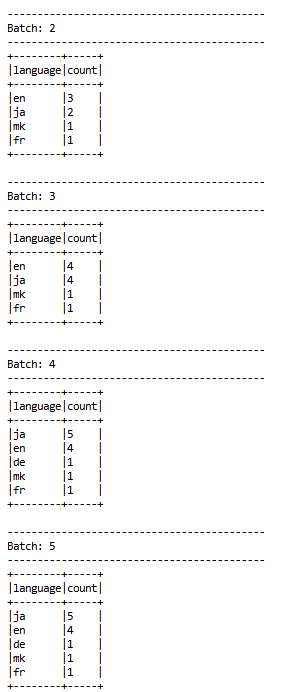
</div>


### Exercici 11.3: Windowed Counting (1 punt)

Bon treball! Has après a realitzar agregacions i a fer un seguiment dels recomptes al llarg del temps. Com vas notar a l'Exercici 2.4, de vegades és més efectiu mantenir aquests recomptes en **finestres de temps específiques**. Ara, volem que apliquis aquesta tècnica utilitzant [functions available in Spark Structured
Streaming](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#window-operations-on-event-time). 
Tingues en compte que Spark Structured Streaming gestiona el temps de manera diferent a Spark Streaming, per la qual cosa hauràs de considerar-ho en analitzar i interpretar els resultats.

La teva tasca és **crear una taula que mostri un recompte de la quantitat de toots originals (recorda filtrar els retweets) realitzats en cada idioma, segmentats dins d'un marc de temps específic.** Per a aquest exercici, has d'usar una sliding window d'un minut, amb les dades refrescant-se cada 5 segons. Aquest enfocament et permetrà monitorar de prop la freqüència dels toots en diferents idiomes al llarg d'intervals breus i superposats.

Et demanem que proporcionis una taula amb l'estructura següent:

- **`window`:** Mostra el rang de temps
- **`language`:** Aquesta columna mostra l'idioma dels toots.
- **`count`:** Aquí és on mostraràs el nombre de toots per a cada idioma.

Els resultats s'han d'**ordenar per finestra de temps i recompte en ordre descendent.**


In [ ]:
# ------------------------------------------------------------
# Inicialització de findspark
# ------------------------------------------------------------
# findspark permet que Python localitzi correctament la instal·lació
# de Spark dins de l'entorn del clúster.
import findspark
findspark.init()


# ------------------------------------------------------------
# Importació de llibreries
# ------------------------------------------------------------
from pyspark.sql import SparkSession
from pyspark import SparkConf, SparkContext

# from_json permet interpretar el JSON del camp value de Kafka.
# col permet seleccionar columnes.
# window permet crear finestres temporals sobre una columna timestamp.
# to_timestamp converteix el camp created_at, que ve com a text, a timestamp.
from pyspark.sql.functions import from_json, col, window, to_timestamp


# ------------------------------------------------------------
# Configuració de Spark
# ------------------------------------------------------------
conf = SparkConf()
conf.setMaster("local[*]")

sc = SparkContext(conf=conf)

# Reduïm el nivell de logs per facilitar la lectura de la sortida.
sc.setLogLevel("ERROR")


# ------------------------------------------------------------
# Creació de la SparkSession
# ------------------------------------------------------------
# El nom de l'aplicació ha d'incloure els usuaris del grup.
app_name = "activity3_3_jbaigesf_mserrar"

spark = SparkSession \
    .builder \
    .appName(app_name) \
    .getOrCreate()


# ------------------------------------------------------------
# Paràmetres de Kafka
# ------------------------------------------------------------
# Broker Kafka del clúster de la pràctica.
kafka_bootstrap_servers = "eimtcld3node1:9092"

# Topic que conté els JSONs dels toots de Mastodon.
kafka_topic = "mastodon_toots"


# ------------------------------------------------------------
# Lectura batch petita per inferir l'esquema
# ------------------------------------------------------------
# Structured Streaming necessita conèixer l'esquema JSON abans
# de poder aplicar from_json() al flux.
#
# Fem una lectura batch petita del topic per inferir l'esquema.
# Utilitzem endingOffsets="latest" perquè l'offset absolut 10 de la
# plantilla provocava errors al nostre entorn.
batch_df = spark \
    .read \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "earliest") \
    .option("endingOffsets", "latest") \
    .load() \
    .limit(10)


# ------------------------------------------------------------
# Inferència de l'esquema JSON
# ------------------------------------------------------------
# Kafka desa el missatge dins la columna value en format binari.
# Primer convertim value a string i després Spark infereix l'esquema.
schema = spark.read.json(
    batch_df
    .selectExpr("CAST(value AS STRING)")
    .rdd
    .map(lambda x: x[0])
).schema

# Mostrem l'esquema inferit per comprovar que conté camps com:
# created_at, language, reblog, account, etc.
print(schema.simpleString())


# ------------------------------------------------------------
# Lectura streaming des de Kafka
# ------------------------------------------------------------
# Llegim el topic en mode streaming.
#
# startingOffsets="latest" evita processar tot l'històric del topic.
# maxOffsetsPerTrigger limita el nombre de missatges processats
# en cada microbatch i ajuda a evitar problemes de memòria.
toots = spark \
    .readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", kafka_topic) \
    .option("startingOffsets", "latest") \
    .option("maxOffsetsPerTrigger", 5) \
    .load()


# ------------------------------------------------------------
# Parseig, filtratge i agregació amb finestra temporal
# ------------------------------------------------------------
# Objectiu:
# Comptar el nombre de toots originals per idioma dins de finestres
# temporals d'1 minut, actualitzades cada 5 segons.
#
# Estructura de sortida demanada:
# - window: rang temporal de la finestra.
# - language: idioma del toot.
# - count: nombre de toots originals d'aquell idioma dins la finestra.
toots_df = (
    toots

    # Convertim el camp value de Kafka a string i l'interpretem com a JSON.
    .select(
        from_json(
            col("value").cast("string"),
            schema
        ).alias("parsed_value")
    )

    # Filtrem només els toots originals.
    # Si reblog és null, el missatge és un toot original.
    # Si reblog conté una estructura, el missatge és un retoot.
    .filter(col("parsed_value.reblog").isNull())

    # Evitem registres sense idioma, perquè l'enunciat demana
    # fer el recompte per idioma.
    .filter(col("parsed_value.language").isNotNull())

    # Seleccionem les columnes necessàries.
    # Convertim created_at a timestamp perquè window() necessita
    # una columna temporal real, no una cadena de text.
    .select(
        to_timestamp(col("parsed_value.created_at")).alias("created_at"),
        col("parsed_value.language").alias("language")
    )

    # Eliminem possibles registres on created_at no s'hagi pogut convertir.
    .filter(col("created_at").isNotNull())

    # Agrupem per finestra temporal i idioma.
    # La finestra dura 1 minut i es recalcula cada 5 segons.
    .groupBy(
        window(col("created_at"), "1 minute", "5 seconds"),
        col("language")
    )

    # Comptem els toots originals de cada idioma dins de cada finestra.
    .count()

    # Ordenem els resultats:
    # 1. Primer per inici de finestra en ordre descendent.
    # 2. Després pel recompte en ordre descendent.
    .orderBy(
        col("window.start").desc(),
        col("count").desc()
    )
)


# ------------------------------------------------------------
# Sortida per consola
# ------------------------------------------------------------
# Aquesta consulta fa una agregació amb finestres temporals.
#
# Utilitzem outputMode("complete") perquè volem veure tota la taula
# agregada en cada microbatch.
#
# L'actualització es fa cada 5 segons, tal com demana l'enunciat.
try:
    query = (
        toots_df
        .writeStream

        # Complete mostra tota la taula agregada a cada microbatch.
        .outputMode("complete")

        # Mostrem els resultats per consola.
        .format("console")

        # No trunquem perquè només mostrem window, language i count.
        .option("truncate", "false")

        # Mostrem un màxim de 30 files per microbatch.
        .option("numRows", 30)

        # Checkpoint propi de l'exercici 11.3.
        # Com que hi ha agregació amb finestra, és recomanable mantenir-lo.
        .option("checkpointLocation", "checkpoint_11_3")

        # Refresquem els resultats cada 5 segons.
        .trigger(processingTime="5 seconds")

        # Iniciem la consulta.
        .start()
    )

    # Mantenim la consulta activa fins que l'aturem manualment.
    query.awaitTermination()

except KeyboardInterrupt:
    # Aturada ordenada si fem CTRL + C.
    query.stop()
    spark.stop()
    sc.stop()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<strong>Resultat de l'exercici 11.3</strong><br><br>

La consulta de <strong>Spark Structured Streaming</strong> s'ha executat correctament i ha generat una taula amb les columnes demanades: <code>window</code>, <code>language</code> i <code>count</code>.<br><br>

La columna <code>window</code> mostra el rang temporal de cada finestra. En aquest exercici hem utilitzat finestres d'<code>1 minute</code> amb un desplaçament de <code>5 seconds</code>. Per això observem finestres consecutives com <code>17:33:25 - 17:34:25</code>, <code>17:33:20 - 17:34:20</code> o <code>17:33:15 - 17:34:15</code>.<br><br>

La columna <code>language</code> indica l'idioma dels toots originals i la columna <code>count</code> mostra quants toots originals d'aquell idioma s'han detectat dins de cada finestra temporal.<br><br>

Els resultats apareixen ordenats per finestra temporal i per recompte en ordre descendent. Això permet veure, per a cada finestra, quins idiomes han tingut més activitat. Per exemple, en diverses finestres l'idioma <code>en</code> apareix amb el recompte més alt, fet que indica que és l'idioma més freqüent en aquests intervals.<br><br>

Com que les finestres són lliscants i se superposen, un mateix toot pot formar part de diverses finestres consecutives. Per aquest motiu, els recomptes entre finestres properes poden ser semblants però no necessàriament iguals.
<strong>Justificació del mode de sortida a l'exercici 11.3</strong><br><br>

En aquest exercici hem utilitzat <code>outputMode("complete")</code> perquè la consulta fa una agregació amb finestres temporals mitjançant <code>groupBy(window(...), language).count()</code>.<br><br>

Això vol dir que els valors de <code>count</code> no corresponen a files independents, sinó a resultats agregats que es poden recalcular i actualitzar a mesura que arriben nous toots dins de cada finestra temporal.<br><br>

El mode <code>append</code> no seria el més adequat en aquest cas, perquè Spark no pot escriure només files noves mentre encara està actualitzant els recomptes de finestres obertes. També podríem considerar <code>update</code>, però en aquest exercici volem veure la taula agregada completa en cada microbatch, ordenada per finestra temporal i recompte.<br><br>

Per aquest motiu, <code>complete</code> és el mode més clar per interpretar els resultats, ja que mostra tota la taula agregada a cada actualització del flux.

Afegeix la captura de pantalla del resultat **aquí**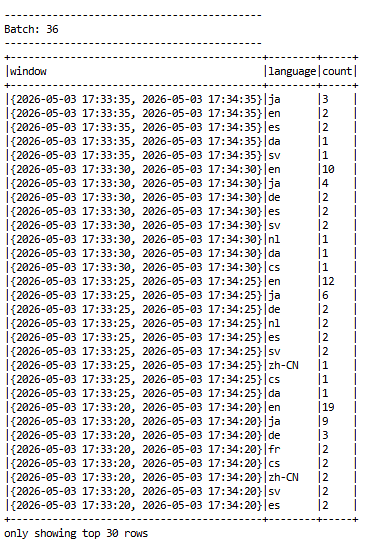
</div>


### Exercici 11.4: Unir Fluxos (1 punt)

En aquest darrer exercici, explorarem una característica molt interessant de Spark Streaming que et permet 
**[unir dos streams](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#stream-stream-joins)
i analitzar-los!**


Per simplificar les coses, ja et proporcionem dos fluxos de dades pre-agregats. 
El primer, que es troba al tema de Kafka **`mastodon_toots_original_domain`**, mostra el recompte de toots originals per a diverses instàncies de Mastodon (recorda que Mastodon és una federació d'instàncies) durant **una finestra fixa d'un minut**. 
El segon flux, al **`mastodon_toots_retoot_domain` topic**, presenta dades similars, però per als toots que són retweets (compartits) d'altres toots. Les dades emmagatzemades als temes de Kafka tenen la mateixa estructura en format JSON:

- Una estructura `window` amb dos elements de tipus `string`: `start` i `end` 
- Un component `string` anomenat `mastodon_instance` amb el topic.
- Un element de tipus `integer` anomenat `count` amb el nombre de toots realitzats en aquell domini en el rang de temps específic.

Donat que l'estructura de les dades és bastant senzilla, aquesta vegada **et demanem que la defineixis manualment**, en lloc d'usar el truc de batch. Un cop hagis configurat les estructures, **hauràs d'obrir un flux per a cada font de Kafka.** El pas següent és unir aquests fluxos. Volem que realitzis una **left join del flux de toots originals amb el flux de retweets**. Després de completar la unió, la teva sortida ha d'incloure:


- **`window`:** el rang de temps
- **`mastodon_instance`:** el domini de la instància de Mastodon
- **`original_count`:** nombre de toots originals publicats en aquell domini durant aquell rang de temps
- **`retweet_count`:** nombre de toots de retweets publicats en aquell domini durant aquell rang de temps

**TIP**: Realitzar una unió en línia de dos fluxos no és una tasca fàcil, i hi ha moltes restriccions que has de respectar. 
Llegeix acuradament [la documentació](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#stream-stream-joins)
i recorda que estem usant la versió 2.4.0. 
A més, recorda que estem realitzant **join over time**, i aquest és un component **clau**. 
Conceptes com els que has après sobre windows són fonamentals juntament amb conceptes com [watermarking](https://downloads.apache.org/spark/docs/3.3.0/structured-streaming-programming-guide.html#stream-stream-joins).
I recorda, **els modes de sortida són complicats** i has de triar-ne un que sigui adequat per a la feina que vols fer.


In [ ]:
# ------------------------------------------------------------
# Inicialització de findspark
# ------------------------------------------------------------
# findspark permet que Python localitzi correctament la instal·lació
# de Spark dins de l'entorn del clúster.
import findspark
findspark.init()


# ------------------------------------------------------------
# Importació de llibreries
# ------------------------------------------------------------
from pyspark.sql import SparkSession
from pyspark import SparkConf, SparkContext

# Tipus necessaris per definir manualment l'esquema dels JSONs.
from pyspark.sql.types import StringType, StructType, StructField, IntegerType

# Funcions de Spark SQL:
# - from_json: interpreta el JSON del camp value de Kafka.
# - col: permet referenciar columnes.
# - to_timestamp: converteix text a timestamp.
# - struct: crea una columna estructurada.
# - coalesce i lit: permeten substituir valors null per 0.
from pyspark.sql.functions import from_json, col, to_timestamp, struct, coalesce, lit


# ------------------------------------------------------------
# Configuració de Spark
# ------------------------------------------------------------
conf = SparkConf()
conf.setMaster("local[*]")

sc = SparkContext(conf=conf)

# Reduïm els logs per fer la sortida més llegible.
sc.setLogLevel("ERROR")


# ------------------------------------------------------------
# Creació de la SparkSession
# ------------------------------------------------------------
# El nom de l'aplicació ha d'incloure els usuaris del grup.
app_name = "activity3_4_jbaigesf_mserrar"

spark = SparkSession \
    .builder \
    .appName(app_name) \
    .getOrCreate()


# ------------------------------------------------------------
# Definició manual de l'esquema d'entrada
# ------------------------------------------------------------
# En aquest exercici l'enunciat ens proporciona l'estructura dels JSONs.
# Per això no cal inferir l'esquema amb una lectura batch.
#
# Cada missatge té:
# - window: una estructura amb start i end.
# - mastodon_instance: domini o instància de Mastodon.
# - count: recompte de toots o retoots en aquella finestra.
schema = StructType([
    StructField(
        "window",
        StructType([
            StructField("start", StringType(), True),
            StructField("end", StringType(), True)
        ]),
        True
    ),
    StructField("mastodon_instance", StringType(), True),
    StructField("count", IntegerType(), True)
])


# ------------------------------------------------------------
# Paràmetres de Kafka
# ------------------------------------------------------------
# Broker Kafka del clúster.
kafka_bootstrap_servers = "eimtcld3node1:9092"

# Topic amb recomptes de toots originals per domini.
toots_original_topic = "mastodon_toots_original_domain"

# Topic amb recomptes de retoots per domini.
toots_retoot_topic = "mastodon_toots_retoot_domain"


# ------------------------------------------------------------
# Lectura del flux de toots originals
# ------------------------------------------------------------
# Llegim el primer topic en mode streaming.
#
# Utilitzem startingOffsets="latest" per evitar processar tot l'històric
# del topic i reduir el risc de problemes de memòria.
#
# maxOffsetsPerTrigger limita el nombre de missatges llegits en cada
# microbatch.
toots_original = spark \
    .readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", toots_original_topic) \
    .option("startingOffsets", "latest") \
    .option("maxOffsetsPerTrigger", 5) \
    .load()


# ------------------------------------------------------------
# Parseig del flux de toots originals
# ------------------------------------------------------------
# Convertim el camp value de Kafka a string i l'interpretem com a JSON
# utilitzant l'esquema definit manualment.
#
# També convertim window.start i window.end a timestamp. Això ens permet
# treballar amb temps d'esdeveniment i aplicar watermark.
toots_original_df = (
    toots_original

    # Interpretem el JSON del camp value.
    .select(
        from_json(
            col("value").cast("string"),
            schema
        ).alias("parsed_value")
    )

    # Seleccionem i preparem les columnes necessàries.
    .select(
        to_timestamp(col("parsed_value.window.start")).alias("window_start"),
        to_timestamp(col("parsed_value.window.end")).alias("window_end"),
        col("parsed_value.mastodon_instance").alias("mastodon_instance"),
        col("parsed_value.count").alias("original_count")
    )

    # Eliminem possibles registres mal formats.
    .filter(col("window_start").isNotNull())
    .filter(col("window_end").isNotNull())
    .filter(col("mastodon_instance").isNotNull())

    # Reconstruïm la columna window amb start i end, tal com demana l'enunciat.
    .select(
        struct(
            col("window_start").alias("start"),
            col("window_end").alias("end")
        ).alias("window"),
        col("window_start"),
        col("window_end"),
        col("mastodon_instance"),
        col("original_count")
    )

    # Watermark sobre el temps de finalització de la finestra.
    # Això ajuda Spark a gestionar l'estat de la unió entre streams.
    .withWatermark("window_end", "2 minutes")
)


# ------------------------------------------------------------
# Lectura del flux de retoots
# ------------------------------------------------------------
# Llegim el segon topic en mode streaming.
toots_retoot = spark \
    .readStream \
    .format("kafka") \
    .option("kafka.bootstrap.servers", kafka_bootstrap_servers) \
    .option("subscribe", toots_retoot_topic) \
    .option("startingOffsets", "latest") \
    .option("maxOffsetsPerTrigger", 5) \
    .load()


# ------------------------------------------------------------
# Parseig del flux de retoots
# ------------------------------------------------------------
# Apliquem el mateix esquema, però ara el camp count representa
# el nombre de retoots.
toots_retoot_df = (
    toots_retoot

    # Interpretem el JSON del camp value.
    .select(
        from_json(
            col("value").cast("string"),
            schema
        ).alias("parsed_value")
    )

    # Preparem les columnes necessàries per a la unió.
    .select(
        to_timestamp(col("parsed_value.window.start")).alias("window_start"),
        to_timestamp(col("parsed_value.window.end")).alias("window_end"),
        col("parsed_value.mastodon_instance").alias("mastodon_instance"),
        col("parsed_value.count").alias("retoot_count")
    )

    # Eliminem possibles registres incomplets o mal formats.
    .filter(col("window_start").isNotNull())
    .filter(col("window_end").isNotNull())
    .filter(col("mastodon_instance").isNotNull())

    # Watermark del segon flux.
    # En una left join entre streams, el watermark és especialment important
    # per poder tancar finestres i descartar estat antic.
    .withWatermark("window_end", "2 minutes")
)


# ------------------------------------------------------------
# Left join entre els dos fluxos
# ------------------------------------------------------------
# Fem una left join perquè volem conservar tots els registres del flux
# de toots originals, encara que no hi hagi cap registre equivalent
# al flux de retoots.
#
# La unió es fa per:
# - mateixa instància de Mastodon,
# - mateix inici de finestra,
# - mateix final de finestra.
#
# També afegim una condició temporal redundant però útil per explicitar
# que la unió es fa sobre la mateixa finestra temporal.
original_alias = toots_original_df.alias("original")
retoot_alias = toots_retoot_df.alias("retoot")

toots_join_df = (
    original_alias
    .join(
        retoot_alias,
        (
            (col("original.mastodon_instance") == col("retoot.mastodon_instance")) &
            (col("original.window_start") == col("retoot.window_start")) &
            (col("original.window_end") == col("retoot.window_end"))
        ),
        "leftOuter"
    )

    # Seleccionem les columnes demanades per l'enunciat.
    .select(
        col("original.window").alias("window"),
        col("original.mastodon_instance").alias("mastodon_instance"),
        col("original.original_count").alias("original_count"),

        # Si no hi ha coincidència al flux de retoots, retoot_count serà null.
        # Amb coalesce el substituïm per 0 perquè la sortida sigui més clara.
        coalesce(
            col("retoot.retoot_count"),
            lit(0)
        ).alias("retoot_count")
    )
)


# ------------------------------------------------------------
# Sortida per consola
# ------------------------------------------------------------
# En una unió entre dos streams, el mode de sortida més adequat és append.
#
# Fem servir append perquè la consulta escriu files resultants de la unió
# quan Spark ja pot emetre-les segons l'estat i els watermarks.
#
# Complete no és adequat aquí perquè no estem mostrant una taula agregada
# global com als exercicis 11.2 i 11.3, sinó el resultat d'una unió
# entre dos fluxos.
try:
    query = (
        toots_join_df
        .writeStream

        # Mode append per emetre les files resultants de la unió.
        .outputMode("append")

        # Mostrem la sortida per consola.
        .format("console")

        # Mostrem totes les columnes sense truncar.
        .option("truncate", "false")

        # Mostrem fins a 100 files per microbatch.
        .option("numRows", 100)

        # Checkpoint propi de l'exercici.
        # La unió entre streams és una operació amb estat, per tant
        # és recomanable tenir checkpoint.
        .option("checkpointLocation", "checkpoint_11_4")

        # Actualitzem la consulta cada 10 segons.
        .trigger(processingTime="10 seconds")

        # Iniciem la consulta.
        .start()
    )

    # Mantenim la consulta activa fins que l'aturem manualment.
    query.awaitTermination()

except KeyboardInterrupt:
    # Aturem correctament la consulta i Spark si fem CTRL + C.
    query.stop()
    spark.stop()
    sc.stop()

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<strong>Resultat de l'exercici 11.4</strong><br><br>

La consulta de <strong>Spark Structured Streaming</strong> s'ha executat correctament i ha generat una taula amb les columnes demanades per l'enunciat: <code>window</code>, <code>mastodon_instance</code>, <code>original_count</code> i <code>retoot_count</code>.<br><br>

En aquest exercici hem llegit dos fluxos de Kafka: un amb els recomptes de toots originals per instància de Mastodon i un altre amb els recomptes de retoots. Després hem aplicat una <code>left join</code> utilitzant com a claus la finestra temporal i la instància de Mastodon.<br><br>

Els resultats mostren, per a cada finestra temporal, el nombre de toots originals i de retoots associats a cada domini. Per exemple, per a la finestra <code>17:50:00 - 17:51:00</code>, observem instàncies com <code>misskey.io</code>, <code>mastodon.online</code>, <code>mastodon.social</code> o <code>m.cmx.im</code>, amb els seus recomptes corresponents.<br><br>

Alguns microbatches poden aparèixer buits. Això és normal en una consulta streaming amb unió de dos fluxos, ja que no en cada microbatch hi ha necessàriament noves coincidències entre el flux de toots originals i el flux de retoots.<br><br>

La utilització de <code>withWatermark()</code> és important perquè Spark pugui gestionar l'estat intern de la unió i descartar dades massa antigues un cop superat el marge temporal definit.
<strong>Interpretació de la left join entre fluxos</strong><br><br>

Hem utilitzat una <code>left join</code> perquè volem conservar tots els registres del flux de toots originals, encara que no sempre existeixi una coincidència equivalent al flux de retoots per a la mateixa finestra temporal i la mateixa instància de Mastodon.<br><br>

Aquesta estratègia permet obtenir una taula comparativa on <code>original_count</code> representa l'activitat original de cada domini i <code>retoot_count</code> representa l'activitat de difusió o compartició associada al mateix domini i interval temporal.<br><br>

D'aquesta manera podem comparar, dins d'una mateixa finestra, quines instàncies generen més contingut original i quines tenen més activitat de retoot.

Afegeix la captura de pantalla del resultat **aquí**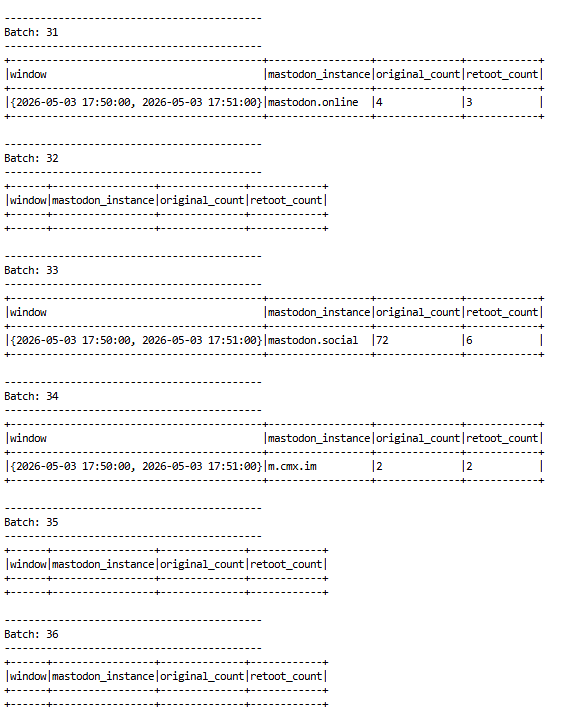
</div>



In [ ]:
# YOUR CODE HERE

### **Exercici 12**: Preguntes teòriques (*2.5 punts*)

Durant l'entrevista final amb cada grup, que es realitzarà mitjançant videotrucada, es revisarà breument la pràctica realitzada.

En l'última part de l'entrevista es plantejaran 4 preguntes teòriques relacionades amb els continguts de la pràctica i del mòdul 5.

- Cada pregunta tindrà una puntuació de 0,625 punts.

- Les preguntes es respondran oralment durant l'entrevista.

- Es valorarà la comprensió dels conceptes teòrics i la capacitat d'explicar-los amb claredat.